# Switching Performance

**RQ3.** What does runtime model switching cost, and what does it save?

Two cases, identical loop, only the plant exchanged:

- **Full FEM** — the deformable model drives the whole horizon. The reference.
- **Switched FEM/FMU** — the region map hands the horizon between the two models.

Both run `HybridAlgorithm` and therefore pay the same detection overhead. Without
contact the baseline has no indicator of its own, so it is given a constant,
never-crossing one; otherwise it would fall back to `GaussSeidelAlgorithm`, take
no trial advance at all, and the switched case would be charged for work the
reference never does.

Set `CONTACT` below to select the regime. Both were previously separate notebooks
that shared 25 definitions by copy.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().resolve().parents[0] / "notebooks"))
sys.path.insert(0, str(Path.cwd().resolve()))

from evidence import repo_root

REPO = repo_root()

import evidence as ev
from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)

plt = set_professional_style(latex=True)

print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


## Configuration

Every parameter of the run is one `Scenario`. It travels with the run and is
written next to the numbers as provenance, so a recorded result cannot be
separated from the configuration that produced it.

In [2]:
CONTACT = True
SMOKE = False

# Campaign B horizon: 1.0 s (evidence_plan.md, Campaign B, decided 2026-09-12).
# It reaches the third contact cluster; 2.0 s only adds impacts of the idealised
# penalty-contact model. Keep 0.4 s for smoke runs only: there the switch count
# is a footnote.
HORIZON_S = 1.0

SCENARIO = ev.CONTACT_SCENARIO if CONTACT else ev.NO_CONTACT_SCENARIO
# Region edges 0.070 / 0.100 rad, as in 03_switching. The packaged 0.070 / 0.080
# let the last rebound of the 1.0 s run cross the exit edge and come back within
# 10 ms, which adds a switch pair that measures nothing (issues.md HYB-09).
SCENARIO = SCENARIO.replace(
    t_end=HORIZON_S, switch_threshold_rad=0.085, switch_band_rad=0.015
)
if SMOKE:
    # Repetitions only. The horizon is NOT shortened: whether the mechanism
    # fires at all depends on it. With the launch gate, the region key only
    # crosses down if |theta| rises slower than gate_offset / gate_t_open
    # (~11.7 rad/s here) *and* the run lasts long enough for |theta| to come
    # back through the band. A 0.1 s smoke horizon silently produced zero
    # switches and a benchmark that measured nothing.
    SCENARIO = SCENARIO.replace(n_warmup=0, n_repeats=1)

# evidence_plan.md section 3: T2 is the runtime table, F5 the runtime
# distribution figure. Both regimes feed the same register rows, so the
# scenario is part of the filename and one does not overwrite the other.
TABLE_ID = f"T2_{SCENARIO.name}"
FIGURE_ID = f"F5_{SCENARIO.name}"
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FMU_PATHS = ev.discover_fmus(REPO, sys.platform)

display(pd.Series(SCENARIO.provenance()).to_frame("value"))

,value
name,contact
contact,True
t0,0.0
t_end,1.0
macro_dt,0.001
fem_internal_dt,0.001
switch_threshold_rad,0.085
switch_band_rad,0.015
region_modes,"[FEM, FMU]"
gate_t_open_s,0.03


## Cases

The baseline is a bare `FEMPendulum`; the switched case is a `SwitchingPendulum`
with the scenario's region map installed. Everything else is shared.

In [3]:
from syssimx_examples.controlled_pendulum.components import FEMPendulum


def build_full_fem():
    plant = FEMPendulum(name=ev.PLANT_NAME, group="Plant")
    plant.set_parameters(**ev.make_fem_parameters(SCENARIO))
    ev.declare_plant_feedthrough(plant)
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Full FEM", detection_probe=True
    )
    return system, plant, {"FEM": plant}


def build_switched():
    plant = ev.SwitchingPendulum(SCENARIO, name=ev.PLANT_NAME).declare_regions()
    plant.set_parameters(**{"FEM": ev.make_fem_parameters(SCENARIO)})
    ev.declare_plant_feedthrough(plant)
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Switched FEM/FMU"
    )
    return system, plant, {"FEM": plant.fem, "FMU": plant.fmu}


CASES = {"Full FEM": build_full_fem, "Switched FEM/FMU": build_switched}

## Execute

Warm-up repetitions are excluded from every summary. The first evaluated
repetition of each case is kept for the figure and the self-checks.

In [4]:
def progress(total, desc):
    return tqdm(total=total, desc=desc, unit=" sim s", leave=False)


# Every repetition's trajectory is kept, not only the first. The contact count
# varies between repetitions at the default thread count (D6), and the variation
# is a reported result, so the trajectories behind it have to survive the run.
# One result is a handful of float arrays plus its event lists; ten of them cost
# a few megabytes and no NGSolve state.
rows, kept, kept_all = [], {}, {}
for repeat in range(SCENARIO.n_warmup):
    for name, builder in CASES.items():
        row, _ = ev.run_measured_case(
            builder, name, repeat, SCENARIO, warmup=True, progress=progress
        )
        rows.append(row)

for repeat in range(SCENARIO.n_repeats):
    for name, builder in CASES.items():
        row, result = ev.run_measured_case(
            builder, name, repeat, SCENARIO,
            keep_result=True, progress=progress,
        )
        rows.append(row)
        if result is not None:
            kept_all.setdefault(name, []).append(result)
            # Repeat 0 remains the representative run for F4 below.
            if repeat == 0:
                kept.setdefault(name, result)

df = pd.DataFrame(rows)
df_eval = df.loc[~df["warmup"]].copy()
print(f"{len(df_eval)} evaluated runs over {SCENARIO.n_repeats} repetitions")

warmup 1 - Full FEM:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

warmup 1 - Switched FEM/FMU:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

repeat 1 - Full FEM:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

repeat 1 - Switched FEM/FMU:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

repeat 2 - Full FEM:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

...

repeat 4 - Full FEM:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

repeat 4 - Switched FEM/FMU:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

repeat 5 - Full FEM:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

repeat 5 - Switched FEM/FMU:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

10 evaluated runs over 5 repetitions


## Trajectory comparison

Deliberately placed **before** the self-checks. Those checks raise on a contact-count
mismatch, and a mismatch is exactly when the trajectory is worth looking at, so a
figure downstream of the assertion would never render on the run that needs it.

The comparison is diagnostic, not evidence. Once the self-checks pass and the run is
a campaign run, this figure is register entry F4.


trajectories cached      : F4_contact_trajectories.npz
contacts            : 14 full FEM, 14 switched
mean bounce gap     : 0.0612 s
paired instants     : all 14 within a quarter gap (max 5.03e-03 s)
max |theta| deviation: 2.995e-02 rad


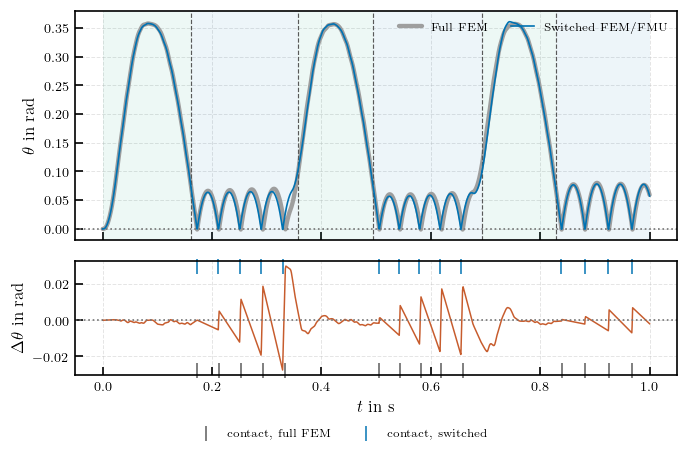

In [5]:
import matplotlib.transforms as mtransforms

from plot_setup import MODEL_COLORS, REFERENCE_STYLE

# The trajectories live in kernel memory only, and this run costs about an hour
# and three quarters. Losing the kernel loses all of it, because record() keeps
# the scalars and nothing keeps theta(t). So cache the arrays on the run that
# produces them and rebuild from the cache when the kernel no longer has them.
CACHE = OUT_DIR / f"F4_{SCENARIO.name}_trajectories.npz"


def _pack(case):
    """The subset of a kept result that this figure needs, as plain arrays."""
    starts, stops, modes = zip(*case["mode_intervals"]) if case["mode_intervals"] else ((), (), ())
    return {
        "t": case["t"],
        "theta": case["theta"],
        "contact_times": np.asarray(case["contact_times"], dtype=float),
        "switch_times": np.asarray([float(e.time) for e in case["switch_events"]]),
        "interval_starts": np.asarray(starts, dtype=float),
        "interval_stops": np.asarray(stops, dtype=float),
        "interval_modes": np.asarray(modes, dtype=object),
    }


def _unpack(store, prefix):
    return {
        "t": store[f"{prefix}_t"],
        "theta": store[f"{prefix}_theta"],
        "contact_times": store[f"{prefix}_contact_times"],
        "switch_times": store[f"{prefix}_switch_times"],
        "mode_intervals": list(zip(
            store[f"{prefix}_interval_starts"],
            store[f"{prefix}_interval_stops"],
            store[f"{prefix}_interval_modes"],
        )),
    }


if "kept" in dir():
    switched = _pack(kept["Switched FEM/FMU"])
    switched["mode_intervals"] = kept["Switched FEM/FMU"]["mode_intervals"]
    baseline = _pack(kept["Full FEM"])
    baseline["mode_intervals"] = kept["Full FEM"]["mode_intervals"]
    np.savez_compressed(
        CACHE,
        **{f"switched_{k}": v for k, v in _pack(kept["Switched FEM/FMU"]).items()},
        **{f"baseline_{k}": v for k, v in _pack(kept["Full FEM"]).items()},
    )
    print(f"trajectories cached      : {CACHE.name}")
else:
    if not CACHE.exists():
        raise RuntimeError(
            f"No trajectories in this kernel and no cache at {CACHE}. "
            f"Run the Execute cell above, which takes about an hour and three "
            f"quarters at this horizon."
        )
    # Read inside the context manager. np.load on a zip archive is lazy and
    # holds the file open, which on Windows blocks the next run from
    # overwriting its own cache.
    with np.load(CACHE, allow_pickle=True) as _store:
        switched = _unpack(_store, "switched")
        baseline = _unpack(_store, "baseline")
    print(f"trajectories loaded from : {CACHE.name} (this kernel did not run them)")

# The two runs do not share a time grid. Event localization inserts steps where
# an indicator crosses, and the cases cross at different instants, so the
# difference has to be taken on a common grid rather than element-wise.
theta_base_on_sw = np.interp(switched["t"], baseline["t"], baseline["theta"])
delta = switched["theta"] - theta_base_on_sw

sw_contacts = np.asarray(switched["contact_times"], dtype=float)
base_contacts = np.asarray(baseline["contact_times"], dtype=float)

# Where do the two bounce sequences part company? Pair them in order while they
# still agree, and report the first pair that does not. That instant, not the
# count, is what a horizon decision needs.
n_pairable = min(sw_contacts.size, base_contacts.size)
paired_offset = np.abs(sw_contacts[:n_pairable] - base_contacts[:n_pairable])
gaps = np.diff(base_contacts)
mean_gap = float(np.mean(gaps)) if gaps.size else float("inf")
diverged = np.flatnonzero(paired_offset > 0.25 * mean_gap)
first_bad = int(diverged[0]) if diverged.size else None

print(f"contacts            : {base_contacts.size} full FEM, {sw_contacts.size} switched")
print(f"mean bounce gap     : {mean_gap:.4f} s")
if first_bad is None:
    print(f"paired instants     : all {n_pairable} within a quarter gap "
          f"(max {paired_offset.max():.2e} s)" if n_pairable else "paired instants     : none")
else:
    print(f"first divergence    : contact {first_bad + 1} at t = "
          f"{base_contacts[first_bad]:.4f} s, offset {paired_offset[first_bad]:.2e} s "
          f"({paired_offset[first_bad] / mean_gap:.0%} of a gap)")
print(f"max |theta| deviation: {np.abs(delta).max():.3e} rad")

fig, (ax_theta, ax_delta) = plt.subplots(
    2, 1, figsize=(FULL_WIDTH, 0.62 * FULL_WIDTH), sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)
for panel_label, panel_ax in zip(("(a)", "(b)"), (ax_theta, ax_delta), strict=True):
    panel_ax.text(0.01, 0.96, panel_label, transform=panel_ax.transAxes,
                  ha="left", va="top", fontsize=9, fontweight="bold")

# Which model drove the switched run, as a background band. The reader needs to
# see whether a deviation starts inside an FMU stretch or at a handover.
for t_start, t_stop, mode in switched["mode_intervals"]:
    ax_theta.axvspan(t_start, t_stop, color=MODEL_COLORS[mode], alpha=0.07, linewidth=0)

ax_theta.plot(baseline["t"], baseline["theta"], label="Full FEM", **REFERENCE_STYLE)
ax_theta.plot(switched["t"], switched["theta"], color=MODEL_COLORS["FEM"],
              linewidth=1.0, label="Switched FEM/FMU", zorder=3)
for t_switch in switched["switch_times"]:
    ax_theta.axvline(float(t_switch), color="0.35", linestyle="--", linewidth=0.7, zorder=2)
ax_theta.axhline(0.0, **{"color": "0.45", "linestyle": ":", "linewidth": 1.0})
ax_theta.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax_theta.grid(True, alpha=0.4)
ax_theta.legend(loc="upper right", fontsize=7, frameon=False, ncol=2)

ax_delta.plot(switched["t"], delta, color="#C75C2D", linewidth=0.9)
ax_delta.axhline(0.0, color="0.45", linestyle=":", linewidth=1.0)
# Contact instants as rugs on opposite edges, so a desynchronizing sequence is
# visible as the two combs drifting apart rather than as a number in a table.
rug = mtransforms.blended_transform_factory(ax_delta.transData, ax_delta.transAxes)
ax_delta.plot(base_contacts, np.full(base_contacts.shape, 0.045), linestyle="none",
              marker="|", markersize=9, color="0.35", transform=rug,
              clip_on=False, label="contact, full FEM")
ax_delta.plot(sw_contacts, np.full(sw_contacts.shape, 0.955), linestyle="none",
              marker="|", markersize=9, color=MODEL_COLORS["FEM"], transform=rug,
              clip_on=False, label="contact, switched")
if first_bad is not None:
    ax_delta.axvline(base_contacts[first_bad], color="#B23A48", linewidth=1.0)
ax_delta.set_xlabel(r"$t$ in $\mathrm{s}$")
ax_delta.set_ylabel(r"$\Delta\theta$ in $\mathrm{rad}$")
ax_delta.grid(True, alpha=0.4)

fig.tight_layout()
# Below the figure: both combs span the full width at the two edges, so any
# in-axes placement sits on one of them.
fig.legend(*ax_delta.get_legend_handles_labels(), loc="lower center",
           bbox_to_anchor=(0.5, -0.04), ncol=2, fontsize=7, frameon=False)
# The .smoke suffix mirrors record(): a reduced run must not leave a file that
# looks like the campaign figure.
_paired_here = base_contacts.size == sw_contacts.size and first_bad is None
_suffix = ".smoke.pdf" if SMOKE else (".pdf" if _paired_here else ".unpaired.pdf")
fig.savefig(OUT_DIR / f"F4_{SCENARIO.name}{_suffix}", bbox_inches="tight")
plt.show()


## Self-checks

A benchmark that silently stopped exercising the mechanism still produces a
speedup number. These raise rather than warn.

In [6]:
switched = kept["Switched FEM/FMU"]
baseline = kept["Full FEM"]

if df_eval.loc[df_eval["case"] == "Switched FEM/FMU", "n_switches"].min() == 0:
    # Say why, rather than only that. The two causes are a horizon that ends
    # before the key re-enters the band, and a launch fast enough that the gated
    # key never leaves the upper region in the first place.
    key_trace = np.abs(switched["theta"]) + SCENARIO.gate_offset_rad * np.clip(
        1.0 - switched["t"] / max(SCENARIO.gate_t_open_s, 1e-12), 0.0, None
    ) if SCENARIO.gated else np.abs(switched["theta"])
    boundary_events = {
        name: len(records)
        for (_c, name), records in switched.get("event_history", {}).items()
        if name.startswith("region_boundary_")
    }
    raise AssertionError(
        "The switched case never left its initial model, so this run measures "
        "nothing about switching.\n"
        f"  reconciled initial mode : {switched['initial_mode']}\n"
        f"  horizon                 : {SCENARIO.t0} .. {SCENARIO.t_end} s\n"
        f"  region key min / max    : {key_trace.min():.4f} / {key_trace.max():.4f} rad\n"
        f"  armed edges             : {SCENARIO.armed_lower_edge:.4f} / "
        f"{SCENARIO.armed_upper_edge:.4f} rad\n"
        f"  region boundary events  : {boundary_events or 'none'}\n"
        "If the key never reaches an armed edge, either the horizon is too short "
        "or the launch is too fast for the gate: the key only crosses down while "
        "|theta| rises slower than gate_offset / gate_t_open."
    )

if SCENARIO.contact:
    counts = df_eval.groupby("case")["n_contacts"].apply(lambda s: sorted(set(s))).to_dict()
    print("contacts per case:", counts)
    # Every impact the FEM resolved on the committed trajectory must have been
    # dispatched, in every evaluated run of both cases. The coordinator's
    # endpoint guard cannot see an episode shorter than a macro step; this is
    # the check that catches a lost contact (HYB-10). Raising here is right:
    # a run that lost a contact is not evidence, timings included.
    lost = df_eval.loc[df_eval["n_closures"] != df_eval["n_contacts"],
                       ["case", "repeat", "n_closures", "n_contacts"]]
    assert lost.empty, (
        "physical gap closures and dispatched wall_hit events differ (HYB-10):\n"
        f"{lost.to_string(index=False)}"
    )
    print("closures == dispatches in every evaluated run")
    if min(min(v) for v in counts.values()) == 0:
        raise AssertionError(
            "No wall contact was resolved. The pendulum starts on the wall_hit zero, so a first "
            "step onto the negative side leaves the falling indicator unable to fire (HYB-01)."
        )
    # Classified, not asserted, since 2026-09-14. A different bounce sequence
    # invalidates the trajectory comparison (F4) and nothing else: the runtime
    # ratio needs no paired sequence. Raising here, before record(), discarded a
    # 2 s run whose timings were valid. With NGSolve at its default thread count
    # the FEM is not bit-reproducible (06_determinism), so a marginal contact can
    # appear in one case and not the other; that is reported, per D6.
    n_base, n_sw = len(baseline["contact_times"]), len(switched["contact_times"])
    if n_base != n_sw:
        trajectory_paired = False
        trajectory_note = (
            f"contact counts differ in repeat 0: {n_base} full FEM against {n_sw} switched"
        )
    else:
        offsets = np.abs(np.array(switched["contact_times"]) - np.array(baseline["contact_times"]))
        gaps = np.diff(baseline["contact_times"])
        mean_interval = float(np.mean(gaps)) if gaps.size else float("inf")
        print(f"max contact-instant offset : {offsets.max():.2e} s "
              f"({offsets.max() / SCENARIO.macro_dt:.1f} macro steps)")
        if offsets.size and offsets.max() > 0.5 * mean_interval:
            trajectory_paired = False
            trajectory_note = (
                f"same contact count, but instants differ by up to {offsets.max():.3e} s, "
                f"more than half the mean bounce interval {mean_interval:.3e} s"
            )
        else:
            trajectory_paired, trajectory_note = True, None
    if trajectory_paired:
        print("trajectory comparison : paired, F4 is admissible")
    else:
        print(f"trajectory comparison : NOT paired ({trajectory_note}). F4 is saved as "
              f"unpaired; the runtime result below is unaffected.")

if not SCENARIO.contact:
    trajectory_paired, trajectory_note = True, None

if SCENARIO.gated:
    # The launch gate must not drive a switch on its own. The run starts in the
    # outer region, whose armed threshold is the lower band edge, so the gated
    # key has to stay above that edge for the whole ramp.
    t = switched["t"]
    ramp = t <= SCENARIO.gate_t_open_s
    key = np.abs(switched["theta"][ramp]) + SCENARIO.gate_offset_rad * np.clip(
        1.0 - t[ramp] / SCENARIO.gate_t_open_s, 0.0, None
    )
    print(f"gated key minimum over ramp: {key.min():.4f} rad "
          f"(armed edge {SCENARIO.armed_lower_edge:.4f} rad)")
    if key.size and key.min() <= SCENARIO.armed_lower_edge:
        raise AssertionError(
            "The gated key falls to the armed edge during the ramp, so the ramp itself triggers "
            "the switch and the model choice encodes this trajectory's schedule."
        )

print("OK: the mechanism was exercised"
      + ("" if trajectory_paired else "; trajectories are not paired, timings still valid"))

contacts per case: {'Full FEM': [14], 'Switched FEM/FMU': [14]}
closures == dispatches in every evaluated run
max contact-instant offset : 5.03e-03 s (5.0 macro steps)
trajectory comparison : paired, F4 is admissible
gated key minimum over ramp: 0.1348 rad (armed edge 0.0700 rad)
OK: the mechanism was exercised


### Contact-sequence consistency across repetitions

The default NGSolve thread count is not bit-reproducible, so the notebook keeps
every repetition's trajectory and verifies the contact and switch counts rather
than assuming one sequence. The cache preserves the evidence behind that check.
If counts differ, the diagnostic below draws the affected trajectories; if they
agree, no additional spread figure is produced.

In [7]:
CACHE_ALL = OUT_DIR / f"F4_{SCENARIO.name}_trajectories_all_repeats.npz"


def _pack_repeat(result):
    return {
        "t": np.asarray(result["t"], dtype=float),
        "theta": np.asarray(result["theta"], dtype=float),
        "contact_times": np.asarray(result["contact_times"], dtype=float),
        "switch_times": np.asarray(
            [float(e.time) for e in result["switch_events"]], dtype=float
        ),
    }


# `case index` keys the archive, because npz keys must be strings and a case
# name carries a slash. The order of CASES is the order of the columns below.
CASE_SLUGS = {name: f"case{i}" for i, name in enumerate(CASES)}

if "kept_all" in dir():
    payload = {"case_names": np.asarray(list(CASES), dtype=object)}
    for name, results in kept_all.items():
        for repeat, result in enumerate(results):
            for key, value in _pack_repeat(result).items():
                payload[f"{CASE_SLUGS[name]}_r{repeat}_{key}"] = value
    np.savez_compressed(CACHE_ALL, **payload)
    repeats_by_case = {
        name: [_pack_repeat(r) for r in results] for name, results in kept_all.items()
    }
    print(f"all repetitions cached   : {CACHE_ALL.name}")
else:
    if not CACHE_ALL.exists():
        raise RuntimeError(
            f"No per-repeat trajectories in this kernel and no cache at {CACHE_ALL}."
        )
    with np.load(CACHE_ALL, allow_pickle=True) as _store:
        names = [str(n) for n in _store["case_names"]]
        repeats_by_case = {}
        for i, name in enumerate(names):
            packed = []
            repeat = 0
            while f"case{i}_r{repeat}_t" in _store:
                packed.append({
                    key: _store[f"case{i}_r{repeat}_{key}"]
                    for key in ("t", "theta", "contact_times", "switch_times")
                })
                repeat += 1
            repeats_by_case[name] = packed
    print(f"all repetitions loaded   : {CACHE_ALL.name} (this kernel did not run them)")

spread = pd.DataFrame([
    {
        "case": name,
        "repeat": i + 1,
        "contacts": len(packed["contact_times"]),
        "switches": len(packed["switch_times"]),
    }
    for name, packed_list in repeats_by_case.items()
    for i, packed in enumerate(packed_list)
])
display(spread.pivot(index="repeat", columns="case",
                     values=["contacts", "switches"]))

for name, packed_list in repeats_by_case.items():
    counts = sorted({len(p["contact_times"]) for p in packed_list})
    verdict = "reproducible" if len(counts) == 1 else "counts differ"
    print(f"{name:20s} contact counts {counts}  ->  {verdict}")

# Draw only the cases whose repetitions disagree; a case that always resolves
# the same sequence has nothing to show and would draw one line ten times.
varying = {
    name: packed_list
    for name, packed_list in repeats_by_case.items()
    if len({len(p["contact_times"]) for p in packed_list}) > 1
}

if not varying:
    print("\nEvery case resolved one contact sequence; no spread figure is drawn.")
else:
    fig, axes = plt.subplots(
        len(varying), 1, sharex=True, squeeze=False,
        figsize=(FULL_WIDTH, 0.34 * FULL_WIDTH * len(varying)),
    )
    for ax, (name, packed_list) in zip(axes[:, 0], varying.items()):
        # One colour per resolved contact count, so the reader sees groups of
        # repetitions rather than ten indistinguishable lines.
        counts = sorted({len(p["contact_times"]) for p in packed_list})
        shades = {n: plt.cm.viridis(0.15 + 0.7 * i / max(len(counts) - 1, 1))
                  for i, n in enumerate(counts)}
        seen = set()
        for i, packed in enumerate(packed_list):
            n = len(packed["contact_times"])
            label = f"{n} contacts" if n not in seen else None
            seen.add(n)
            ax.plot(packed["t"], packed["theta"], lw=0.9, color=shades[n],
                    alpha=0.85, label=label)
            ax.plot(packed["contact_times"],
                    np.full(len(packed["contact_times"]), -0.004 - 0.006 * i),
                    "|", ms=5, color=shades[n])
        ax.axhline(0.0, color="0.45", lw=0.8, ls=":")
        ax.set_ylabel(r"$\theta$ in rad")
        ax.set_title(f"{name}: {len(packed_list)} repetitions", fontsize=9, loc="left")
        ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=len(counts))
    axes[-1, 0].set_xlabel("$t$ in s")
    fig.tight_layout()
    spread_path = OUT_DIR / (
        f"F4b_{SCENARIO.name}_repeat_spread{'' if not SMOKE else '.smoke'}.pdf"
    )
    fig.savefig(spread_path, bbox_inches="tight")
    print(f"\nspread figure written    : {spread_path.name}")
    plt.show()


all repetitions cached   : F4_contact_trajectories_all_repeats.npz


contacts                  switches                 
case   Full FEM Switched FEM/FMU Full FEM Switched FEM/FMU
repeat                                                    
1            14               14        0                5
2            14               14        0                5
3            14               14        0                5
4            14               14        0                5
5            14               14        0                5

Full FEM             contact counts [14]  ->  reproducible
Switched FEM/FMU     contact counts [14]  ->  reproducible

Every case resolved one contact sequence; no spread figure is drawn.


## Result

`run_speedup` is the headline. `accepted_speedup` divides out the detection
overhead that both cases pay, and should track the inverse FEM duty cycle: if the
FEM is active for a fraction *f* of the horizon and dominates the cost, accepted
model time scales with *f*. `discarded` is the share of model time that is
computed and rolled back — a property of hybrid detection, not of switching.

In [8]:
paired = df_eval.pivot(index="repeat", columns="case", values="run_s")
ratio = paired["Full FEM"] / paired["Switched FEM/FMU"]

summary = df_eval.groupby("case", sort=False).agg(
    run_s=("run_s", "median"),
    solve_s=("solve_s", "median"),
    accepted_s=("solve_accepted_s", "median"),
    overhead_s=("overhead_s", "median"),
    fem_active_sim_s=("fem_active_sim_s", "median"),
    n_switches=("n_switches", "median"),
)
ref = summary.loc["Full FEM"]
summary["run_speedup"] = ref["run_s"] / summary["run_s"]
summary["accepted_speedup"] = ref["accepted_s"] / summary["accepted_s"]
summary["overhead_share"] = summary["overhead_s"] / summary["run_s"]
summary["fem_duty"] = summary["fem_active_sim_s"] / SCENARIO.sim_time

discarded = {
    case: float(
        sum(sub[f"solve_{p}_s"].median() for p in ev.DISCARDED_PHASES)
        / max(sub["solve_s"].median(), 1e-12)
    )
    for case, sub in df_eval.groupby("case", sort=False)
}
summary["discarded"] = pd.Series(discarded)

display(summary.style.format({
    "run_s": "{:.2f}", "solve_s": "{:.2f}", "accepted_s": "{:.2f}",
    "overhead_s": "{:.3f}", "fem_active_sim_s": "{:.3f}", "n_switches": "{:.0f}",
    "run_speedup": "{:.2f}x", "accepted_speedup": "{:.2f}x",
    "overhead_share": "{:.1%}", "fem_duty": "{:.1%}", "discarded": "{:.1%}",
}))

print(f"paired run speedup : median {ratio.median():.2f}x  "
      f"spread {ratio.max() - ratio.min():.2f}")
print(f"1 / FEM duty cycle : {1.0 / summary.loc['Switched FEM/FMU', 'fem_duty']:.2f}x "
      f"(expected accepted speedup)")

,run_s,solve_s,accepted_s,overhead_s,fem_active_sim_s,n_switches,run_speedup,accepted_speedup,overhead_share,fem_duty,discarded
case,,,,,,,,,,,
Full FEM,3463.85,3418.56,1604.02,45.291,1.000,0,1.00x,1.00x,1.3%,100.0%,53.1%
Switched FEM/FMU,1916.06,1883.66,824.32,31.800,0.565,5,1.81x,1.95x,1.7%,56.5%,56.2%


paired run speedup : median 1.83x  spread 0.07
1 / FEM duty cycle : 1.77x (expected accepted speedup)


In [9]:
record(
    TABLE_ID,
    {
        "run_speedup_paired_median": float(ratio.median()),
        "run_speedup_paired": [float(v) for v in ratio],
        "accepted_speedup": float(summary.loc["Switched FEM/FMU", "accepted_speedup"]),
        "fem_duty_cycle": float(summary.loc["Switched FEM/FMU", "fem_duty"]),
        "overhead_share": {k: float(v) for k, v in summary["overhead_share"].items()},
        "discarded_model_time": {k: float(v) for k, v in summary["discarded"].items()},
        "n_switches_median": float(summary.loc["Switched FEM/FMU", "n_switches"]),
        "event_counts_per_repeat": df_eval[
            ["case", "repeat", "n_switches", "n_contacts", "n_closures"]
        ].to_dict("records"),
        # Repeat 0 supplies F4. These metrics are computed on the common grid
        # used by the figure and quantify the trajectory panel without treating
        # it as a fidelity bound.
        "trajectory_comparison": {
            "paired": trajectory_paired,
            "reason": trajectory_note,
            "max_abs_delta_rad": float(np.abs(delta).max()),
            "max_contact_pair_offset_s": (
                float(paired_offset.max()) if paired_offset.size else None
            ),
            "mean_contact_gap_s": mean_gap if np.isfinite(mean_gap) else None,
            "n_contact_pairs": int(n_pairable),
        },
        "run_s_median": {k: float(v) for k, v in summary["run_s"].items()},
        "scenario": SCENARIO.provenance(),
    },
    directory=RESULTS,
    notebook="04_performance",
    smoke=SMOKE,
)

WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/T2_contact.json')

## Figure

The figure reports the paired wall-time ratios from all five evaluated
repetitions. The median is shown beside the accepted-work ratio and the inverse
FEM duty cycle. It contains no absolute wall times, which depend on machine
state and are not paper claims.

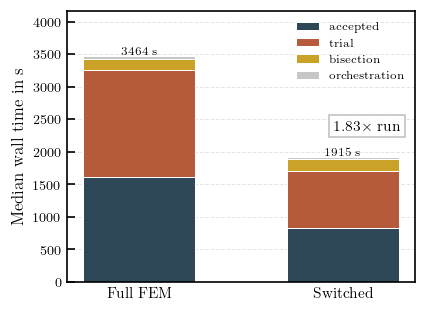

In [10]:
ratio_values = ratio.to_numpy(dtype=float)
jitter = np.linspace(-0.09, 0.09, ratio_values.size)
ratio_median = float(np.median(ratio_values))
accepted_ratio = float(summary.loc["Switched FEM/FMU", "accepted_speedup"])
inverse_duty = 1.0 / float(summary.loc["Switched FEM/FMU", "fem_duty"])

fig, ax = plt.subplots(figsize=(0.68 * FULL_WIDTH, 0.48 * FULL_WIDTH))

ax.scatter(jitter, ratio_values, s=28, marker="o", color="#0072B2",
           edgecolor="white", linewidth=0.5, zorder=3, label="Paired repetition")
ax.plot(0.0, ratio_median, marker="D", markersize=6, color="0.15",
        linestyle="none", zorder=4, label="Median")
ax.plot(1.0, accepted_ratio, marker="s", markersize=6, color="#D55E00",
        linestyle="none", zorder=4)
ax.plot(2.0, inverse_duty, marker="^", markersize=7, color="#009E73",
        linestyle="none", zorder=4)

for xpos, value in ((0.0, ratio_median), (1.0, accepted_ratio), (2.0, inverse_duty)):
    ax.annotate(rf"${value:.2f}\times$", (xpos, value), xytext=(0, 7),
                textcoords="offset points", ha="center", va="bottom", fontsize=8)

ax.axhline(1.0, color="0.55", linestyle=":", linewidth=0.9)
ax.set_xlim(-0.35, 2.35)
ax.set_ylim(0.95, max(accepted_ratio, ratio_values.max(), inverse_duty) + 0.18)
ax.set_xticks([0.0, 1.0, 2.0])
ax.set_xticklabels(["Wall time\n5 paired runs", "Accepted\nmodel work", r"$1/f_{\mathrm{FEM}}$"])
ax.set_ylabel("Full-FEM / switched ratio")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower left", frameon=False, fontsize=7)

fig.tight_layout()
fig.savefig(OUT_DIR / f"{FIGURE_ID}.pdf", bbox_inches="tight")
plt.show()

## Reading the result

Absolute timings move with machine state. The paper therefore reports the five
paired ratios, their median, and the repetition count.

**The discarded share is a detection cost.** A configuration that never
switches discards a similar fraction to the switched configuration.
`_detect_crossings` advances each event source across the macro step and restores
it. If no crossing is found, Gauss-Seidel then advances the accepted interval.

**Bisection cost depends on the available bracket.** With contact,
`FEMPendulum` reports its internal bracketing interval. Without contact, a
switch is bisected from the macro-step interval. Both regimes use the same
`tol_time` of 1e-5 s.

**The duty cycle explains the scale, not the exact ratio.** The inverse FEM duty
cycle is a cost reference. Accepted work also contains the FMU and coupled
participants, so equality is not expected.